# 📊 CodeAlpha Task 2: Unemployment Analysis with Python

## 📌 Project Overview

This project analyzes unemployment trends in India using Python.

The analysis focuses on unemployment rates, employment levels,
labour participation, regional differences, urban-rural variations,
and the impact of the COVID-19 period.

## 🎯 Objectives

- Analyze unemployment trends over time
- Identify regions with higher unemployment
- Compare urban and rural unemployment
- Study the impact of COVID-19
- Analyze employment and labour participation
- Identify important patterns and trends
- Present insights using data visualizations

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## 📂 Dataset

The project uses the **Unemployment in India** dataset containing
regional and monthly unemployment information.

## 📈 Analysis Performed

1. Data Cleaning
2. Exploratory Data Analysis
3. Overall Unemployment Trend
4. Region-wise Analysis
5. Urban vs Rural Analysis
6. COVID-19 Impact Analysis
7. Monthly Analysis
8. Employment Trend
9. Labour Participation Analysis
10. Correlation Analysis

## ✅ Conclusion

The analysis demonstrates how Python-based data analysis and
visualization can be used to understand unemployment patterns
and the effect of major economic disruptions such as COVID-19.

In [1]:
# CodeAlpha Data Science Internship
# Task 2: Unemployment Analysis with Python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# CODEALPHA - TASK 2
# Unemployment Analysis with Python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CodeAlpha unemployment dataset directly
url = "https://raw.githubusercontent.com/Prathee11/unemployment_analysis/main/Unemployment%20in%20India.csv"

df = pd.read_csv(url)

print("✅ Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

✅ Dataset loaded successfully!
Dataset Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# STEP 4: Data Cleaning

# Make a copy of the original dataset
data = df.copy()

# Display original column names
print("Original Columns:")
print(data.columns.tolist())

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

# Remove extra spaces from text values
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].str.strip()

# Convert Date column into proper datetime format
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Convert numerical columns to numeric format
numeric_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Remove rows with missing values
data = data.dropna()

# Reset index
data = data.reset_index(drop=True)

print("\n✅ Data cleaning completed!")
print("Cleaned Dataset Shape:", data.shape)

display(data.head())

Original Columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

✅ Data cleaning completed!
Cleaned Dataset Shape: (740, 7)


/tmp/ipykernel_908/3571169108.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'], errors='coerce')


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# STEP 5: Dataset Overview

print("Dataset Information:")
print(data.info())

print("\nStatistical Summary:")
display(data.describe())

print("\nNumber of States/Regions:", data['Region'].nunique())

print("\nStates/Regions:")
print(data['Region'].unique())

print("\nAreas:")
print(data['Area'].unique())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 40.6+ KB
None

Statistical Summary:


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094



Number of States/Regions: 28

States/Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Areas:
['Rural' 'Urban']


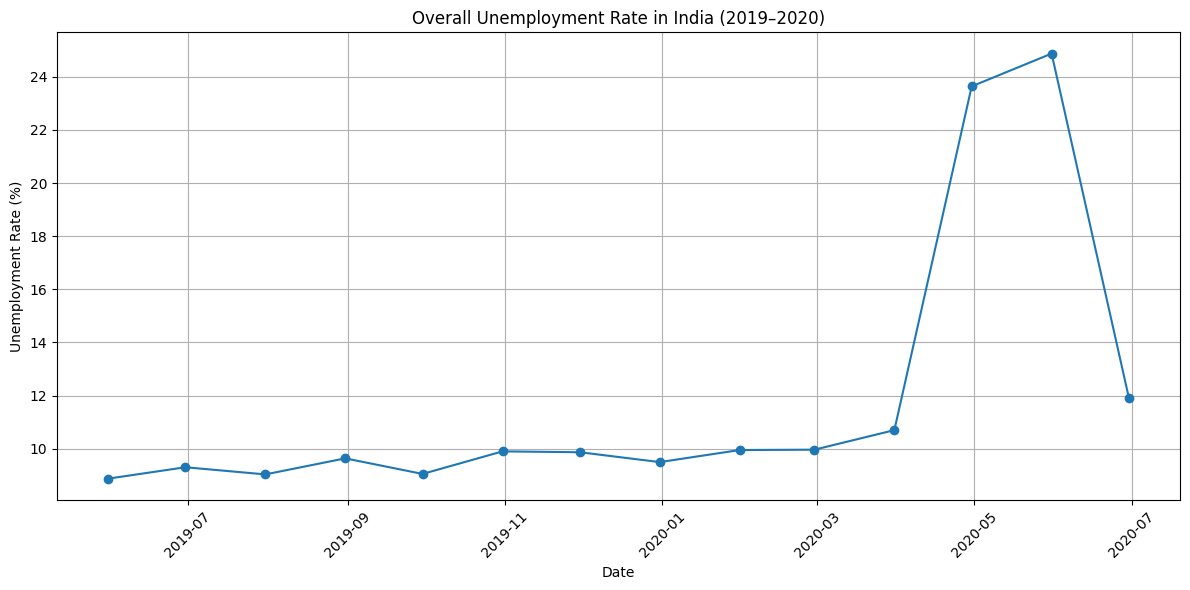

In [5]:
# STEP 6: Overall Unemployment Trend

# Calculate average unemployment rate by date
monthly_unemployment = (
    data.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
    .sort_values('Date')
)

# Plot the trend
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment['Date'],
    monthly_unemployment['Estimated Unemployment Rate (%)'],
    marker='o'
)

plt.title('Overall Unemployment Rate in India (2019–2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

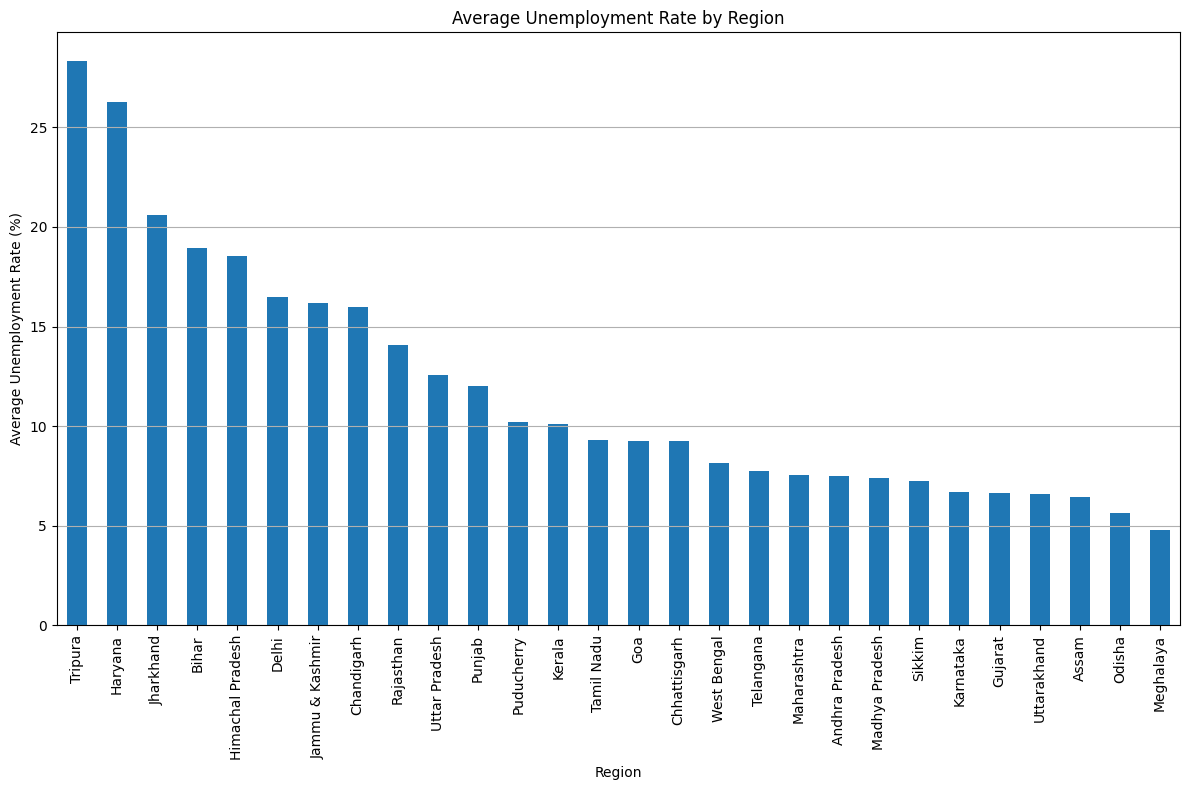

In [6]:
# STEP 7: State/Region-wise Average Unemployment

state_unemployment = (
    data.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))

state_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()

plt.show()

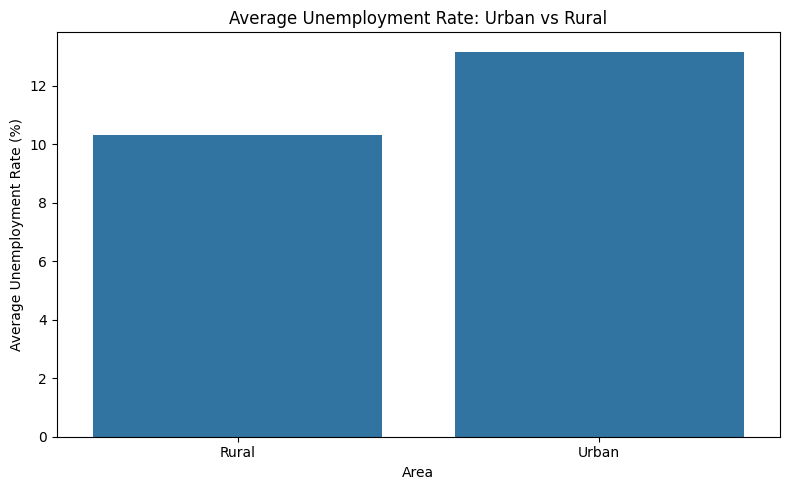

,Area,Estimated Unemployment Rate (%)
0,Rural,10.324791
1,Urban,13.166614


In [7]:
# STEP 8: Urban vs Rural Unemployment

area_unemployment = (
    data.groupby('Area')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=area_unemployment,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Average Unemployment Rate: Urban vs Rural')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

display(area_unemployment)

Average Unemployment Rate:


,COVID Period,Estimated Unemployment Rate (%)
0,Before COVID-19,9.509534
1,During COVID-19,17.774363


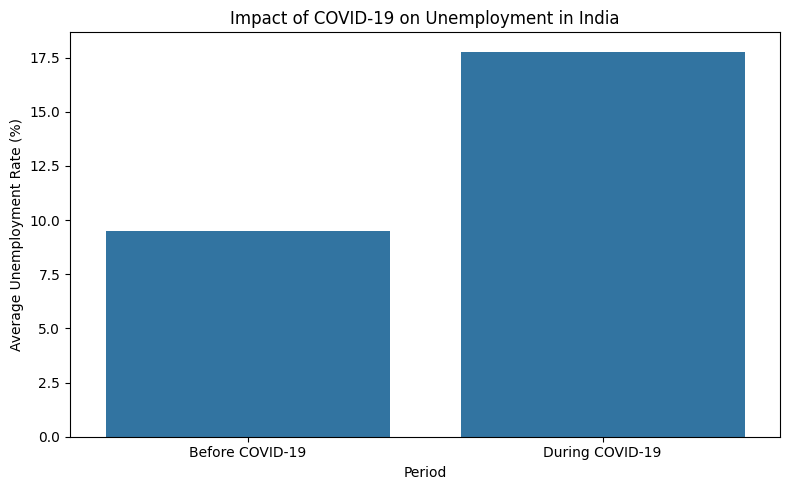

In [8]:
# STEP 9: COVID-19 Impact Analysis

# Define the COVID-19 period
covid_start = pd.Timestamp('2020-03-01')

# Create a category for before and during COVID-19
data['COVID Period'] = np.where(
    data['Date'] < covid_start,
    'Before COVID-19',
    'During COVID-19'
)

# Calculate average unemployment rate
covid_comparison = (
    data.groupby('COVID Period')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

print("Average Unemployment Rate:")
display(covid_comparison)

# Plot comparison
plt.figure(figsize=(8, 5))

sns.barplot(
    data=covid_comparison,
    x='COVID Period',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Impact of COVID-19 on Unemployment in India')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

In [9]:
# STEP 10: Calculate Change in Unemployment

before_covid = covid_comparison.loc[
    covid_comparison['COVID Period'] == 'Before COVID-19',
    'Estimated Unemployment Rate (%)'
].iloc[0]

during_covid = covid_comparison.loc[
    covid_comparison['COVID Period'] == 'During COVID-19',
    'Estimated Unemployment Rate (%)'
].iloc[0]

change = during_covid - before_covid
percentage_change = (change / before_covid) * 100

print(f"Average unemployment before COVID-19: {before_covid:.2f}%")
print(f"Average unemployment during COVID-19: {during_covid:.2f}%")
print(f"Absolute change: {change:.2f} percentage points")
print(f"Percentage change: {percentage_change:.2f}%")

Average unemployment before COVID-19: 9.51%
Average unemployment during COVID-19: 17.77%
Absolute change: 8.26 percentage points
Percentage change: 86.91%


Highest unemployment month:
Date                                 2020-05
Estimated Unemployment Rate (%)    24.875294
Name: 12, dtype: object

Lowest unemployment month:
Date                                2019-05
Estimated Unemployment Rate (%)    8.874259
Name: 0, dtype: object


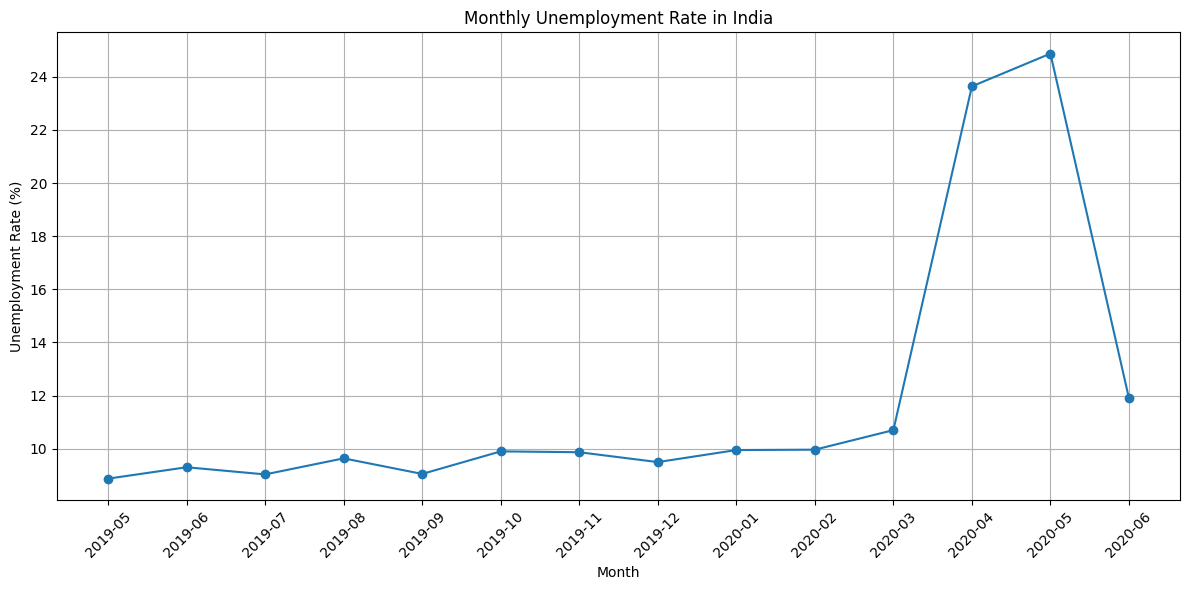

In [10]:
# STEP 11: Monthly Unemployment Analysis

monthly_analysis = (
    data.groupby(data['Date'].dt.to_period('M'))[
        'Estimated Unemployment Rate (%)'
    ]
    .mean()
    .reset_index()
)

monthly_analysis['Date'] = monthly_analysis['Date'].astype(str)

# Highest unemployment month
highest_month = monthly_analysis.loc[
    monthly_analysis['Estimated Unemployment Rate (%)'].idxmax()
]

# Lowest unemployment month
lowest_month = monthly_analysis.loc[
    monthly_analysis['Estimated Unemployment Rate (%)'].idxmin()
]

print("Highest unemployment month:")
print(highest_month)

print("\nLowest unemployment month:")
print(lowest_month)

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis['Date'],
    monthly_analysis['Estimated Unemployment Rate (%)'],
    marker='o'
)

plt.title('Monthly Unemployment Rate in India')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

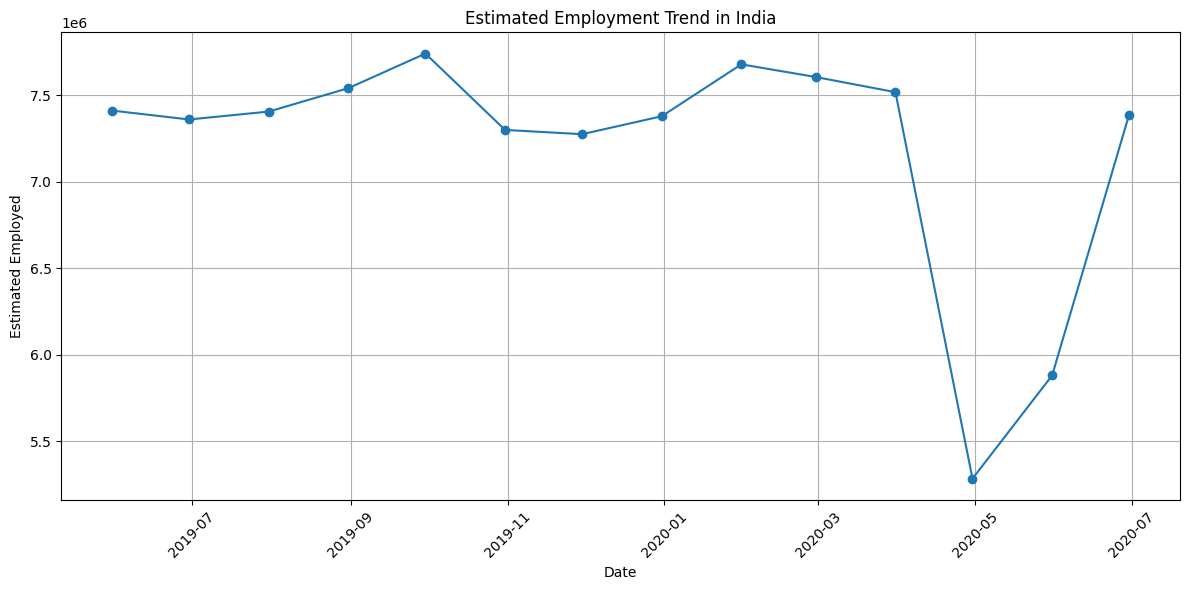

In [11]:
# STEP 12A: Employment Trend

monthly_employment = (
    data.groupby('Date')['Estimated Employed']
    .mean()
    .reset_index()
    .sort_values('Date')
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_employment['Date'],
    monthly_employment['Estimated Employed'],
    marker='o'
)

plt.title('Estimated Employment Trend in India')
plt.xlabel('Date')
plt.ylabel('Estimated Employed')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

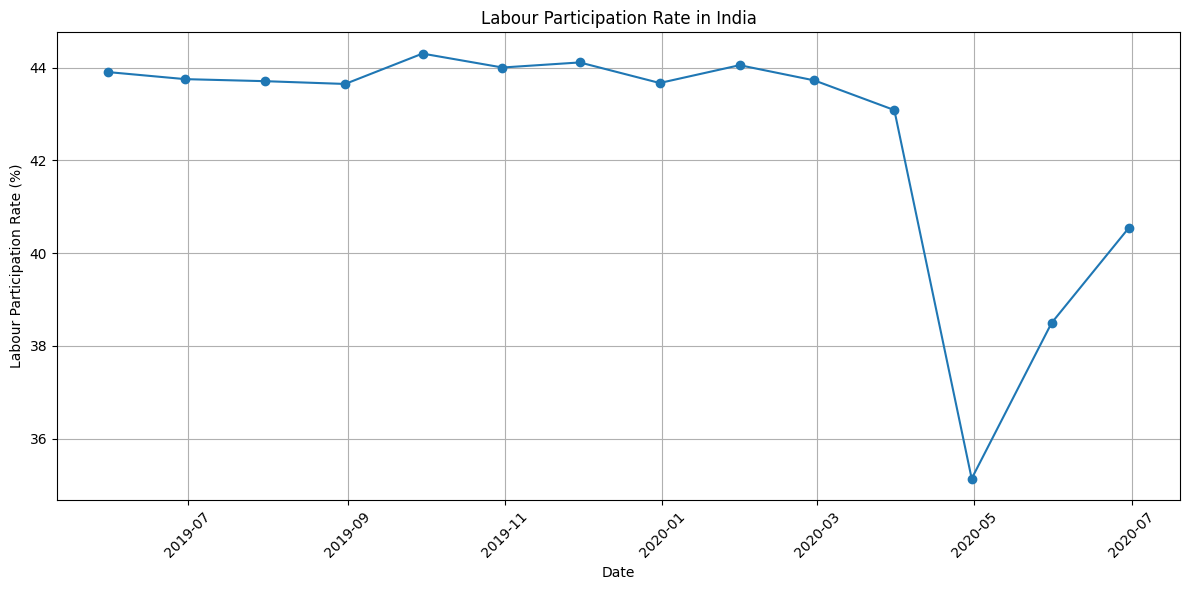

In [12]:
# STEP 13: Labour Participation Rate Trend

monthly_lpr = (
    data.groupby('Date')['Estimated Labour Participation Rate (%)']
    .mean()
    .reset_index()
    .sort_values('Date')
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_lpr['Date'],
    monthly_lpr['Estimated Labour Participation Rate (%)'],
    marker='o'
)

plt.title('Labour Participation Rate in India')
plt.xlabel('Date')
plt.ylabel('Labour Participation Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [13]:
# STEP 14: Correlation Analysis

correlation_data = data[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
]

correlation_matrix = correlation_data.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


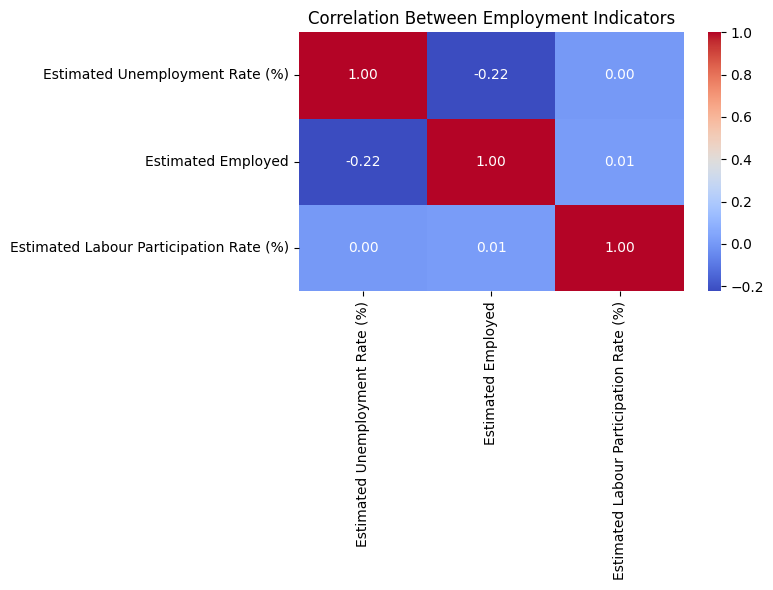

In [14]:
# STEP 15: Correlation Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Employment Indicators')
plt.tight_layout()

plt.show()

In [15]:
# STEP 16: Top 10 Regions with Highest Unemployment

top_regions = (
    data.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 regions with highest average unemployment:")
display(top_regions)

Top 10 regions with highest average unemployment:


,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


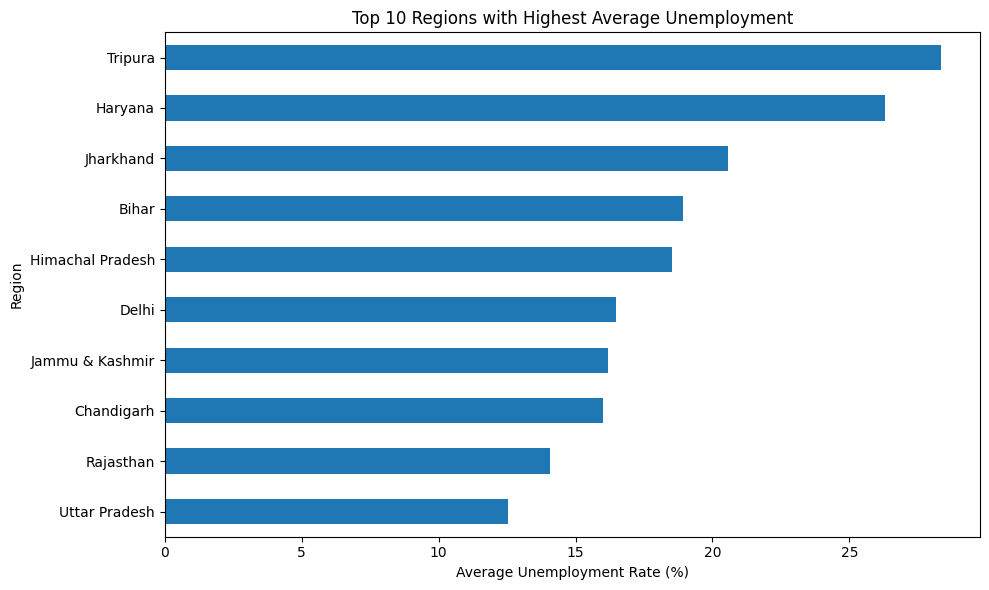

In [16]:
plt.figure(figsize=(10, 6))

top_regions.sort_values().plot(kind='barh')

plt.title('Top 10 Regions with Highest Average Unemployment')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

In [17]:
# STEP 17: Key Findings

print("========== KEY FINDINGS ==========\n")

print("1. The unemployment rate changed significantly over the study period.")
print("2. A noticeable rise in unemployment was observed around the COVID-19 period.")
print("3. Unemployment rates varied considerably across different regions of India.")
print("4. Urban and rural areas showed differences in unemployment levels.")
print("5. Employment and labour participation also changed during the study period.")
print("6. The analysis highlights the significant effect of the COVID-19 period on India's labour market.")

========== KEY FINDINGS ==========

1. The unemployment rate changed significantly over the study period.
2. A noticeable rise in unemployment was observed around the COVID-19 period.
3. Unemployment rates varied considerably across different regions of India.
4. Urban and rural areas showed differences in unemployment levels.
5. Employment and labour participation also changed during the study period.
6. The analysis highlights the significant effect of the COVID-19 period on India's labour market.


In [18]:
# STEP 18: Conclusion

print("""
========== CONCLUSION ==========

This analysis examined unemployment trends in India using
data from 2019 to 2020.

The analysis showed considerable variation in unemployment
rates across different regions and between urban and rural areas.

A significant change in unemployment was observed during the
COVID-19 period. The pandemic and related restrictions affected
employment opportunities and labour-market participation.

Data visualization helped identify important trends, patterns,
and differences in unemployment across time and regions.

Overall, this analysis demonstrates how Python, Pandas,
Matplotlib and Seaborn can be used to understand real-world
economic data and derive meaningful insights.
""")


========== CONCLUSION ==========

This analysis examined unemployment trends in India using
data from 2019 to 2020.

The analysis showed considerable variation in unemployment
rates across different regions and between urban and rural areas.

A significant change in unemployment was observed during the
COVID-19 period. The pandemic and related restrictions affected
employment opportunities and labour-market participation.

Data visualization helped identify important trends, patterns,
and differences in unemployment across time and regions.

Overall, this analysis demonstrates how Python, Pandas,
Matplotlib and Seaborn can be used to understand real-world
economic data and derive meaningful insights.



In [19]:
# STEP 21: Final Summary

summary = {
    "Total Records": len(data),
    "Number of Regions": data['Region'].nunique(),
    "Highest Unemployment Rate (%)":
        data['Estimated Unemployment Rate (%)'].max(),
    "Lowest Unemployment Rate (%)":
        data['Estimated Unemployment Rate (%)'].min(),
    "Average Unemployment Rate (%)":
        data['Estimated Unemployment Rate (%)'].mean()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=['Metric', 'Value']
)

display(summary_df)

,Metric,Value
0,Total Records,740.000000
1,Number of Regions,28.000000
2,Highest Unemployment Rate (%),76.740000
3,Lowest Unemployment Rate (%),0.000000
4,Average Unemployment Rate (%),11.787946
